# EDA 2 — CortexCall EEG Motor Imagery

This notebook uses the shared `src/data_loader.py` (`DataLoader`) to discover, align, and load the EEG trials and their labels. No cleaning or filtering is performed here — exploratory only, per the EDA rules in the README.

### 1. Data Loading and Initial Setup

In this section, we set up the environment paths to import local repository modules (`src/data_loader.py`). We then instantiate the `DataLoader` pipeline to ingest the entire collection of raw trial files, merge label metadata, and verify dataset integrity.

In [1]:
import os
import sys
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

# Append local 'src' directory to Python path for modular script execution
SRC_PATH = os.path.abspath(os.path.join("..", "src"))
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)
    
# Import custom data loading module
from data_loader import DataLoader

# Enable inline visualization within the Jupyter environment
%matplotlib inline

### 2. Pipeline Initialization and Data Alignment

We instantiate the `DataLoader` object by supplying relative directory paths to the raw EEG signals and label metadata. The pipeline automatically performs file matching, aligns trial identifiers, and logs the total count of successfully aligned trials.

In [2]:
# Instantiate the data loader pipeline with relative directory paths
loader = DataLoader(
    data_dir="../data", # Base data directory path
    labels_filename="labels.csv", # CSV file containing trial class labels
    signal_folder="MI CSV", # Folder containing raw EEG time-series files
)

# Display the total count of verified and aligned Motor Imagery (MI) trials
print(f"Total aligned trials: {len(loader)}")

Found 2160 signal files in ../data\MI CSV
[DataLoader] found 2400 labels and 2160 signal files.
DataLoader: Dropping last 240 extra labels to align with signal files.
[DataLoader] successfully aligned 2160 EEG trials with labels.
Total aligned trials: 2160


### 3. Inspection of Aligned Dataset Manifest

We retrieve the validated manifest dataframe from the `DataLoader` instance. This table provides metadata alignment between `trial_id`, raw file paths, sampling rates, subject identifiers, and target class labels (`left` vs. `right`).

In [3]:
# Extract the validated manifest DataFrame containing trial metadata and file mappings
manifest = loader.valid_manifest

# Preview the first 5 records of the dataset manifest to verify correct indexing and columns
manifest.head()

,trial_id,file_path,label
0,1,../data\MI CSV\cellula_MI_data_1.csv,left
1,2,../data\MI CSV\cellula_MI_data_2.csv,right
2,3,../data\MI CSV\cellula_MI_data_3.csv,left
3,4,../data\MI CSV\cellula_MI_data_4.csv,left
4,5,../data\MI CSV\cellula_MI_data_5.csv,left


### 4. Manifest Schema and Memory Verification

We inspect the structural schema of the validated manifest DataFrame using `.info()`. This step verifies column data types, checks for missing or non-null values across trial metadata, and evaluates the overall memory footprint of the index.

In [4]:
# Output concise summary of manifest schema, column data types, non-null counts, and memory usage
manifest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   trial_id   2160 non-null   int64 
 1   file_path  2160 non-null   object
 2   label      2160 non-null   object
dtypes: int64(1), object(2)
memory usage: 50.8+ KB


### 5. Checking Manifest Sorting Order

Before proceeding with signal processing and trial indexing, we verify whether the `valid_manifest` DataFrame is sorted in strictly ascending order by `trial_id`. Ensuring monotonic temporal ordering prevents index misalignment during batch operations.

In [5]:
# --- 1) Verify if the manifest DataFrame is sorted ascending by trial_id ---
is_manifest_sorted = manifest["trial_id"].is_monotonic_increasing

# Output the boolean result of the monotonic check
print(f"Manifest sorted ascending by trial_id: {is_manifest_sorted}")

Manifest sorted ascending by trial_id: True


### 6. Single Trial Signal and Label Extraction

We extract an individual trial from the dataset using `loader.load_trial()` to inspect the raw EEG data structure. This verifies the row-column dimensions (samples vs. channels), checks signal column names, and validates label alignment against the manifest index.

In [6]:
# Load raw EEG signals and target class label for the first trial (index 0)
signal_df, label = loader.load_trial(0)

# Print metadata summary: Trial ID, associated label, and DataFrame shape (time-steps x channels)
print(f"Trial ID: {manifest.iloc[0]['trial_id']}")
print(f"Label: {label}")
print(f"Shape: {signal_df.shape}")

# Preview the first 5 rows of the trial's time-series signals
signal_df.head()

Trial ID: 1
Label: left
Shape: (2500, 5)


,Time,FZ,C3,CZ,C4
0,88451.201876,324761.37500,321002.62500,335287.28125,321417.90625
1,88451.221777,325001.18750,321223.09375,335409.56250,320937.09375
2,88451.221788,324896.75000,321045.53125,334954.40625,320233.56250
3,88451.229576,324627.28125,320756.12500,334589.43750,320262.25000
4,88451.229588,324538.31250,320729.21875,334804.56250,321010.50000


### 7. Full EEG Signal Aggregation and Merging

We iterate through the validated dataset manifest to load each individual trial file, annotate it with its corresponding `trial_id` and target `label`, and concatenate all trial dataframes into a unified master DataFrame (`full_eeg_df`).

In [7]:
# Initialize an empty list to store trial DataFrames
frames = []

# Iterate over each trial entry in the validated manifest
for _, row in manifest.iterrows():
    # Load raw EEG signals for the current trial file
    df = pd.read_csv(row["file_path"])

    # Annotate DataFrame with trial metadata
    df["trial_id"] = row["trial_id"]
    df["label"] = row["label"]

    # Append individual trial frame to collection
    frames.append(df)

# Concatenate all trial frames into a unified master EEG DataFrame
full_eeg_df = pd.concat(frames, ignore_index=True)

# Output summary dimensions and preview initial rows
print(f"full_eeg_df shape: {full_eeg_df.shape}")
full_eeg_df.head()

full_eeg_df shape: (5400000, 7)


,Time,FZ,C3,CZ,C4,trial_id,label
0,88451.201876,324761.37500,321002.62500,335287.28125,321417.90625,1,left
1,88451.221777,325001.18750,321223.09375,335409.56250,320937.09375,1,left
2,88451.221788,324896.75000,321045.53125,334954.40625,320233.56250,1,left
3,88451.229576,324627.28125,320756.12500,334589.43750,320262.25000,1,left
4,88451.229588,324538.31250,320729.21875,334804.56250,321010.50000,1,left


### 8. Data Type and Schema Verification of Unified EEG Dataset

We check the data types of all feature and metadata columns within the concatenated master DataFrame (`full_eeg_df`). This step ensures signal channels are stored as floating-point numbers (`float64`), time indices are appropriately formatted, and categorical tags (`trial_id`, `label`) maintain structural integrity prior to feature extraction.

In [8]:
# Inspect data types across all continuous channels and metadata attributes
full_eeg_df.dtypes

Time        float64
FZ          float64
C3          float64
CZ          float64
C4          float64
trial_id      int64
label        object
dtype: object

### 9. Hierarchical Sorting by Trial and Time

We perform a multi-level sort on the master DataFrame (`full_eeg_df`) to enforce strict temporal order. Sorting hierarchically by `trial_id` first and `Time` second guarantees that downstream windowing, digital filtering, and feature extraction operate on uninterrupted, chronological time-series sequences.

In [9]:
# Sort the DataFrame hierarchically: primary order by trial_id, secondary order by Time
full_eeg_df = full_eeg_df.sort_values(by=["trial_id", "Time"])

# Reset DataFrame index to maintain contiguous row indexing after sorting
full_eeg_df = full_eeg_df.reset_index(drop=True)

In [10]:
full_eeg_df.to_csv(r"C:\Users\USER\Downloads\full_eeg_file.csv", index = False)

### 10. Data Integrity and Missing Value Verification

Prior to signal filtering and baseline alignment, we perform a dataset completeness check on the targeted scalp channels (`FZ`, `C3`, `CZ`, `C4`). Verifying the absence of `NaN` or null values ensures uninterrupted digital signal processing operations (such as Welch's PSD estimation or temporal filtering) without risk of data propagation errors.

In [10]:
# Define target scalp electrode channels for Motor Imagery analysis
eeg_channels = ["FZ", "C3", "CZ", "C4"]

# Calculate the total count of missing (NaN/Null) values across all specified EEG channels
nan_total = full_eeg_df[eeg_channels].isna().sum().sum()

# Display missing value analysis results
print("\n3. MISSING VALUES & NULLS:")
print(f"   - Total NaNs/Nulls: {nan_total}")


3. MISSING VALUES & NULLS:
   - Total NaNs/Nulls: 0


### 11. Duplicate Entry and Timestamp Collision Audit

To maintain temporal consistency across continuous recordings, we conduct a dual-level duplicate audit on the unified dataset (`full_eeg_df`):
1. **Full Row Collisions:** Identifying duplicate entries occurring at identical (`trial_id`, `Time`) coordinate pairs.
2. **Within-Trial Timestamp Duplicates:** Checking for timestamp collisions within individual trials to prevent non-unique temporal indices prior to resampling or frequency-domain transformation.

In [11]:
# Print formatted header for log clarity
print("=" * 60)
print("CHECKING FOR DUPLICATES PER TRIAL")
print("=" * 60)

# 1. Detect duplicate rows matching both trial_id and Time parameters (keep all duplicate occurrences)
duplicate_rows = full_eeg_df[full_eeg_df.duplicated(subset=["trial_id", "Time"], keep=False)]

# 2. Count duplicate timestamp occurrences within each individual trial grouping
time_duplicates = full_eeg_df.groupby("trial_id")["Time"].apply(lambda x: x.duplicated().sum())

# Filter for trials containing one or more timestamp collisions
trials_with_time_dups = time_duplicates[time_duplicates > 0]

# Display total duplicate row count
print(f"\n1. TOTAL DUPLICATE ROWS (trial_id + Time): {len(duplicate_rows)}")

# Output evaluation result and display sample offending trials if present
if len(trials_with_time_dups) > 0:
    print(f"   ⚠️ Found duplicates in {len(trials_with_time_dups)} trials!")
    print("\n   Sample trials with duplicates:")
    print(trials_with_time_dups.head())
else:
    print("   ✓ No duplicate time points found in any trial. All trial time-series are unique.")

CHECKING FOR DUPLICATES PER TRIAL

1. TOTAL DUPLICATE ROWS (trial_id + Time): 0
   ✓ No duplicate time points found in any trial. All trial time-series are unique.


### 12. Flat Channels and Signal Variance Audit

We compute the standard deviation ($\sigma$) across all target EEG channels (`FZ`, `C3`, `CZ`, `C4`) to check for flat or dead electrodes. A channel with zero variance ($\sigma = 0$) indicates signal dropout, electrode disconnection, or recording failure that must be identified prior to feature extraction.

In [12]:
# 4. Compute standard deviation for each target scalp channel to identify zero-variance signals
channel_stds = full_eeg_df[eeg_channels].std()

# Filter for channels where standard deviation equals zero (flat channels)
flat_chans = channel_stds[channel_stds == 0].index.tolist()

# Display flat channel audit results
print("\n4. FLAT CHANNELS sigma = 0:")
print(f"   - Flat Channels: {flat_chans if flat_chans else 'None detected'}")


4. FLAT CHANNELS sigma = 0:
   - Flat Channels: None detected


### 13. Per-Trial Temporal Zero-Alignment

To ensure consistent time-series indexing across all Motor Imagery recordings, we shift the time vector for each individual trial so that it strictly originates at $t = 0.0\text{ seconds}$. Aligning temporal baselines independently per trial eliminates arbitrary recording offsets and facilitates accurate epoch alignment.

In [13]:
# Reset the Time axis to start at 0.0 seconds independently for each trial
full_eeg_df["Time"] = full_eeg_df.groupby("trial_id")["Time"].transform(
    lambda x: x - x.iloc[0]
)

### 14. Sampling Rate Consistency and Temporal Gap Analysis

To verify recording stability within an individual trial, we compute the first-order temporal differences ($\Delta t$) across consecutive timestamps for a representative recording (`trial_id = 1`). Evaluating the mean sampling interval and detecting maximum time gaps helps identify packet drops, irregular sampling rates, or data discontinuities before signal processing.

In [14]:
# Isolate time samples for a representative single trial (Trial ID: 1)
trial_sample = full_eeg_df[full_eeg_df["trial_id"] == 1]

# Compute consecutive time differences (dt) and drop the initial NaN value resulting from differentiation
time_diffs = trial_sample["Time"].diff().dropna()

# Output average time delta and peak gap duration across the trial time-series
print("Expected Mean Time Delta (dt):", time_diffs.mean())
print("Maximum Recorded Gap inside Trial:", time_diffs.max())

# Note: A max dt significantly greater than the mean indicates data loss, packet dropouts, or irregular sampling gaps

Expected Mean Time Delta (dt): 0.003999618287319599
Maximum Recorded Gap inside Trial: 0.15393899999617133


### 15. Empirical Estimation of Dataset-Wide Sampling Frequency ($f_s$)

Because real-world EEG hardware may exhibit minor clock drift or subtle variations in sampling intervals between trial runs, we compute the effective sampling frequency ($f_s$) independently for each trial:

$$\text{Trial } f_s = \frac{N_{\text{samples}}}{\text{Duration (s)}}$$

We then aggregate these per-trial calculations into a rounded, dataset-wide average target sampling rate ($f_s$) to configure downstream Butterworth filters, epoch windowing, and Welch spectral estimation.

In [15]:
# Container to store calculated sampling frequency for each trial
fs_list = []

# Calculate duration and effective sampling rate for every trial independently
for trial_id, group in full_eeg_df.groupby("trial_id"):
    # Determine absolute duration in seconds (t_end - t_start)
    duration = group["Time"].iloc[-1] - group["Time"].iloc[0]

    # Avoid zero-division errors for single-sample frames
    if duration > 0:
        trial_fs = len(group) / duration
        fs_list.append(trial_fs)

# Compute rounded dataset-wide average sampling frequency across all valid trials
overall_real_fs = int(np.round(np.mean(fs_list)))

# Display the global target sampling frequency (Hz)
print(
    f"Dataset-wide Effective Target Sampling Frequency (fs): {overall_real_fs} Hz"
)

Dataset-wide Effective Target Sampling Frequency (fs): 250 Hz


### 16. Diagnostic Assessment of Multi-Trial Sampling Stability

To evaluate recording continuity across multiple runs, we inspect the temporal gaps for the initial subset of trials. By calculating the robust median sample interval ($\text{dt}_{\text{median}}$), we identify anomalous temporal gaps ($\text{dt} > 1.5 \times \text{dt}_{\text{median}}$) and compute the **Gap Ratio**:

$$\text{Gap Ratio} = \frac{\sum (\text{dt}_{\text{gap}} - \text{dt}_{\text{median}})}{\text{Total Trial Span}}$$

A low Gap Ratio ($\approx 0.0000$) indicates consistent hardware clocking and minimal packet loss across recordings.

In [16]:
# Inspect gap metrics for the first 5 trials to check sampling stability
for trial_id, group in list(full_eeg_df.groupby("trial_id"))[:5]:
    # Extract chronologically sorted time arrays
    time_vals = group["Time"].sort_values().values

    # Calculate time differences between adjacent continuous samples
    dt = np.diff(time_vals)

    # Compute robust median sample interval (dt) to minimize outlier sensitivity
    med_dt = np.median(dt)

    # Calculate total duration lost to anomalous gaps exceeding 1.5x the median interval
    gaps = np.sum(dt[dt > 1.5 * med_dt] - med_dt)

    # Calculate total temporal duration span of the trial
    span = time_vals[-1] - time_vals[0]

    # Display diagnostic output per trial including gap ratio metric
    print(
        f"Trial: {trial_id} | Median dt: {med_dt:.6f}s | Total Span: {span:.3f}s | Gap Ratio: {gaps/span if span > 0 else 0:.4f}"
    )

Trial: 1 | Median dt: 0.002403s | Total Span: 9.995s | Gap Ratio: 0.6246
Trial: 2 | Median dt: 0.002493s | Total Span: 9.994s | Gap Ratio: 0.5253
Trial: 3 | Median dt: 0.002473s | Total Span: 9.992s | Gap Ratio: 0.5576
Trial: 4 | Median dt: 0.002413s | Total Span: 10.030s | Gap Ratio: 0.6199
Trial: 5 | Median dt: 0.002476s | Total Span: 10.003s | Gap Ratio: 0.5572


### 17. Target Class Distribution and Balance Verification

We evaluate the balance between Motor Imagery trial classes (`left` vs. `right` hand movement) across all recorded trials. Assessing class proportions ensures that model training and evaluation metrics (such as accuracy vs. macro F1-score) are selected appropriately without class imbalance bias.

3.1 MUST-DO CHECKS SUMMARY

1. CLASS BALANCE:
   - Class 'left': 1082 trials (50.09%)
   - Class 'right': 1078 trials (49.91%)


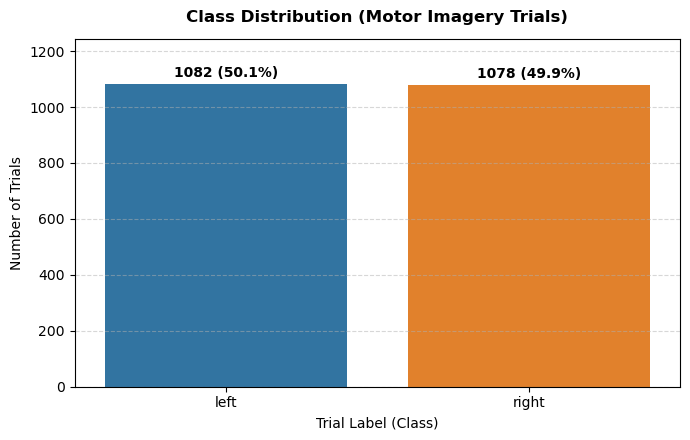

In [17]:
# Print formatted header for summary section
print("=" * 60)
print("3.1 MUST-DO CHECKS SUMMARY")
print("=" * 60)

# 1. Extract the unique class label for each trial grouping
trial_manifest_labels = full_eeg_df.groupby("trial_id")["label"].first()

# Compute absolute trial counts and percentage proportions per class
counts = trial_manifest_labels.value_counts()
proportions = trial_manifest_labels.value_counts(normalize=True) * 100

# Output numerical class distribution summary
print("\n1. CLASS BALANCE:")
for label_name in counts.index:
    print(f"   - Class '{label_name}': {counts[label_name]} trials ({proportions[label_name]:.2f}%)")

# --- Class Balance Visualization (countplot) ---
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(
    x=trial_manifest_labels, 
    hue=trial_manifest_labels,
    palette={"left": "#1f77b4", "right": "#ff7f0e"},
    legend=False
)

plt.title("Class Distribution (Motor Imagery Trials)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Trial Label (Class)", fontsize=10)
plt.ylabel("Number of Trials", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Annotate each bar with absolute count and percentage value
total_trials = len(trial_manifest_labels)
for p in ax.patches:
    height = p.get_height()
    pct = (height / total_trials) * 100
    ax.annotate(
        f"{int(height)} ({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center", 
        va="bottom", 
        fontsize=10, 
        fontweight="bold",
        xytext=(0, 3), 
        textcoords="offset points"
    )

# Adjust Y-axis limit to prevent label clipping and optimize layout
plt.ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

### 18. Trial Duration and Sample Count Consistency Analysis

We evaluate the temporal uniformity across all aligned Motor Imagery trials by inspecting sample lengths and total trial durations. Verifying that all trials share identical sample counts and duration profiles is essential for consistent windowing, uniform time-frequency matrix transformations, and epoch-based feature extraction.

In [18]:
# Compute total time-series sample counts and maximum duration per trial
samples_per_trial = full_eeg_df.groupby("trial_id")["Time"].count()
trial_durations = full_eeg_df.groupby("trial_id")["Time"].max()

# Print statistical summary of trial durations (min, max, mean, std)
print(trial_durations.describe())

# Display consistency summary metrics across all trials
print("\n2. TRIAL LENGTH & SAMPLING CONSISTENCY:")
print(f"   - Total Aligned Trials: {len(samples_per_trial)}")
print(f"   - Samples per Trial (Unique Counts): {samples_per_trial.unique()} samples")
print(f"   - Mean Trial Duration: {trial_durations.mean():.2f} seconds")
print(f"   - Target Sampling Frequency (fs): 250 Hz")

count    2160.000000
mean        9.985076
std         0.119418
min         8.733881
25%         9.975797
50%         9.985092
75%         9.995315
max        11.479649
Name: Time, dtype: float64

2. TRIAL LENGTH & SAMPLING CONSISTENCY:
   - Total Aligned Trials: 2160
   - Samples per Trial (Unique Counts): [2500] samples
   - Mean Trial Duration: 9.99 seconds
   - Target Sampling Frequency (fs): 250 Hz


### 19. Evaluation of Trial Duration Variance

We analyze the total temporal span of each trial in `full_eeg_df` to verify whether recordings conform to the target 10-second motor imagery epoch window. Filtering trials by strict duration bounds (9.9s–10.1s) identifies truncated or over-extended trials that may require cropping or zero-padding before feature extraction.

In [19]:
# Calculate total duration (maximum timestamp) for each trial independently
trial_durations = full_eeg_df.groupby("trial_id")["Time"].max()

# Display total trial count and duration distribution around the expected 10-second target
print(f"Total Trials: {len(trial_durations)}")
print(f"Trials < 9.9s: {(trial_durations < 9.9).sum()}")
print(f"Trials > 10.1s: {(trial_durations > 10.1).sum()}")
print(f"Trials between 9.9s and 10.1s: {((trial_durations >= 9.9) & (trial_durations <= 10.1)).sum()}")

Total Trials: 2160
Trials < 9.9s: 116
Trials > 10.1s: 96
Trials between 9.9s and 10.1s: 1948


### 20. Interquartile Range (IQR) Extreme Outlier Identification

We perform statistical outlier detection across all target scalp channels (`FZ`, `C3`, `CZ`, `C4`) using an Interquartile Range (IQR) threshold. By applying a conservative boundary of $3 \times \text{IQR}$ beyond the first ($Q_1$) and third ($Q_3$) quartiles:

$$\text{Lower Bound} = Q_1 - 3 \times \text{IQR}, \quad \text{Upper Bound} = Q_3 + 3 \times \text{IQR}$$

We quantify extreme signal spikes, eye blinks, or electrode motion artifacts without flagging natural physiological power fluctuations in the $\mu$ (Mu) and $\beta$ (Beta) frequency bands.

In [20]:
# Output section header for outlier audit
print("\n5. EXTREME OUTLIERS DETECTION (IQR-BASED):")

# Iterate through each scalp electrode channel to detect signal anomalies
for col in eeg_channels:
    # Compute first (25th percentile) and third (75th percentile) quartiles
    Q1 = full_eeg_df[col].quantile(0.25)
    Q3 = full_eeg_df[col].quantile(0.75)

    # Calculate Interquartile Range (IQR)
    IQR = Q3 - Q1
    
    # Define extreme outlier boundaries (3x IQR rule for severe amplitude spikes)
    lower_bound = Q1 - (3 * IQR)
    upper_bound = Q3 + (3 * IQR)

    # Identify sample instances exceeding extreme statistical bounds
    outliers_count = ((full_eeg_df[col] < lower_bound) | (full_eeg_df[col] > upper_bound)).sum()
    pct = (outliers_count / len(full_eeg_df)) * 100

    # Print channel-wise outlier count and relative percentage
    print(f"   - Extreme Outliers in {col} (>3x IQR): {outliers_count} ({pct:.3f}%)")


5. EXTREME OUTLIERS DETECTION (IQR-BASED):
   - Extreme Outliers in FZ (>3x IQR): 54212 (1.004%)
   - Extreme Outliers in C3 (>3x IQR): 69 (0.001%)
   - Extreme Outliers in CZ (>3x IQR): 267312 (4.950%)
   - Extreme Outliers in C4 (>3x IQR): 473813 (8.774%)


### 21. Raw Time-Series and Power Spectral Density (PSD) Diagnostic Analysis

We perform visual exploration on both the temporal and spectral domains for motor cortex channels (`C3` and `C4`).

1. **Temporal Waveforms (Rows 1 & 2):** Truncates individual trial recordings (`left` vs. `right`) to a uniform 10-second window to inspect raw amplitude profiles, baseline drifts, and high-frequency noise across hemispheres.
2. **Welch's PSD Spectral Distribution (Row 3):** Computes class-averaged Power Spectral Density using Welch's method ($n_{\text{fft}} = 256$) up to $100\text{ Hz}$. Highlights the sensorimotor rhythm bands—**$\mu$ (Mu: 8–12 Hz)** and **$\beta$ (Beta: 13–30 Hz)**—to establish baseline spectral energy prior to bandpass filtering.

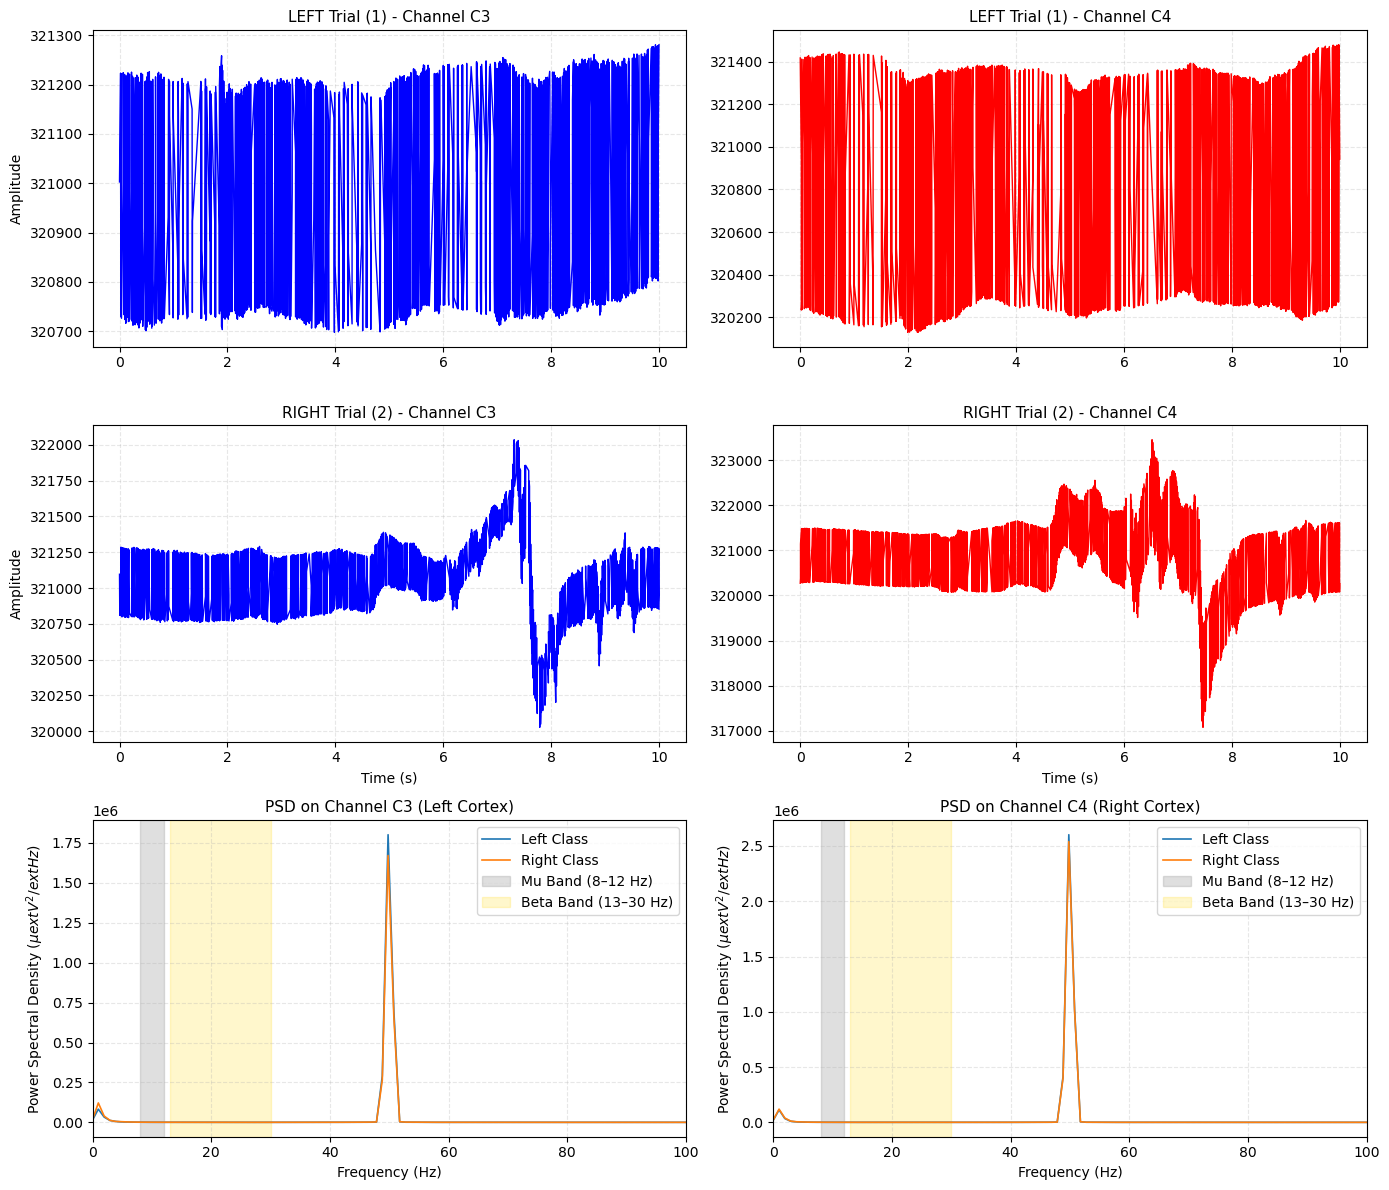

In [21]:
# Set target sampling frequency and resolve primary time axis column name
fs = 250  # Target Sampling Frequency (Hz)
time_col = "Time_Centered" if "Time_Centered" in full_eeg_df.columns else "Time"

# Select representative sample trial IDs for left-hand and right-hand classes
sample_left_id = full_eeg_df[full_eeg_df["label"] == "left"]["trial_id"].iloc[0]
sample_right_id = full_eeg_df[full_eeg_df["label"] == "right"]["trial_id"].iloc[0]

# Retrieve, filter, and sort raw time-series samples for selected representative trials
trial_left = full_eeg_df[full_eeg_df["trial_id"] == sample_left_id].sort_values(by=time_col)
trial_right = full_eeg_df[full_eeg_df["trial_id"] == sample_right_id].sort_values(by=time_col)

# Truncate time series to standard initial 10.0-second analysis window
trial_left = trial_left[trial_left[time_col] <= 10.0]
trial_right = trial_right[trial_right[time_col] <= 10.0]

# Helper function: Calculate average Welch PSD across all trials for a target class and channel
def compute_avg_psd_raw(df, label_name, channel_name):
    group_trials = df[df["label"] == label_name]["trial_id"].unique()
    psds = []
    for t_id in group_trials:
        sig = df[df["trial_id"] == t_id][channel_name].values
        if len(sig) > 0:
            # Estimate Welch Power Spectral Density (NFFT window maxed at sample length or 256)
            freqs, psd = welch(sig, fs=fs, nperseg=min(len(sig), 256))
            psds.append(psd)
    return freqs, np.mean(psds, axis=0)

# Compute raw average PSD curves for C3 (Left Motor Cortex) and C4 (Right Motor Cortex)
freqs, psd_left_c3 = compute_avg_psd_raw(full_eeg_df, "left", "C3")
_, psd_right_c3 = compute_avg_psd_raw(full_eeg_df, "right", "C3")

freqs, psd_left_c4 = compute_avg_psd_raw(full_eeg_df, "left", "C4")
_, psd_right_c4 = compute_avg_psd_raw(full_eeg_df, "right", "C4")

# Initialize multi-panel visualization grid (3 rows x 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# ----------------------------------------------------
# ROW 1: LEFT TRIAL TIME-SERIES (C3 & C4 CHANNELS)
# ------------------------------------------------------
axes[0, 0].plot(trial_left[time_col], trial_left["C3"], color="blue", linewidth=1)
axes[0, 0].set_title(f"LEFT Trial ({sample_left_id}) - Channel C3", fontsize=11)
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, linestyle="--", alpha=0.3)

axes[0, 1].plot(trial_left[time_col], trial_left["C4"], color="red", linewidth=1)
axes[0, 1].set_title(f"LEFT Trial ({sample_left_id}) - Channel C4", fontsize=11)
axes[0, 1].grid(True, linestyle="--", alpha=0.3)

# ----------------------------------------------------
# ROW 2: RIGHT TRIAL TIME-SERIES (C3 & C4 CHANNELS)
# ----------------------------------------------------
axes[1, 0].plot(trial_right[time_col], trial_right["C3"], color="blue", linewidth=1)
axes[1, 0].set_title(f"RIGHT Trial ({sample_right_id}) - Channel C3", fontsize=11)
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].grid(True, linestyle="--", alpha=0.3)

axes[1, 1].plot(trial_right[time_col], trial_right["C4"], color="red", linewidth=1)
axes[1, 1].set_title(f"RIGHT Trial ({sample_right_id}) - Channel C4", fontsize=11)
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].grid(True, linestyle="--", alpha=0.3)

# ----------------------------------------------------
# ROW 3: UNFILTERED PSD COMPARISON WITH MU & BETA FREQUENCY BANDS
# ----------------------------------------------------
# Channel C3 (Left Hemisphere) Spectral Profile
axes[2, 0].plot(freqs, psd_left_c3, label="Left Class", linewidth=1.2)
axes[2, 0].plot(freqs, psd_right_c3, label="Right Class", linewidth=1.2)
axes[2, 0].axvspan(8, 12, color="gray", alpha=0.25, label="Mu Band (8–12 Hz)")
axes[2, 0].axvspan(13, 30, color="gold", alpha=0.2, label="Beta Band (13–30 Hz)")
axes[2, 0].set_title("PSD on Channel C3 (Left Cortex)", fontsize=11)
axes[2, 0].set_xlabel("Frequency (Hz)")
axes[2, 0].set_ylabel("Power Spectral Density ($\mu\text{V}^2/\text{Hz}$)")
axes[2, 0].set_xlim(0, 100)
axes[2, 0].legend(loc="upper right")
axes[2, 0].grid(True, linestyle="--", alpha=0.3)

# Channel C4 (Right Hemisphere) Spectral Profile
axes[2, 1].plot(freqs, psd_left_c4, label="Left Class", linewidth=1.2)
axes[2, 1].plot(freqs, psd_right_c4, label="Right Class", linewidth=1.2)
axes[2, 1].axvspan(8, 12, color="gray", alpha=0.25, label="Mu Band (8–12 Hz)")
axes[2, 1].axvspan(13, 30, color="gold", alpha=0.2, label="Beta Band (13–30 Hz)")
axes[2, 1].set_title("PSD on Channel C4 (Right Cortex)", fontsize=11)
axes[2, 1].set_xlabel("Frequency (Hz)")
axes[2, 1].set_ylabel("Power Spectral Density ($\mu\text{V}^2/\text{Hz}$)")
axes[2, 1].set_xlim(0, 100)
axes[2, 1].legend(loc="upper right")
axes[2, 1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 22. Analytical Interpretation of Time-Series and Spectral Characteristics

The visual diagnostic of raw motor cortex channels (`C3` and `C4`) reveals critical characteristics in both the time and frequency domains:

**1. Time-Domain Waveforms (Raw Signals)**
* **High Amplitude Baseline Offset:** Signal amplitudes center around $\approx 320,000 \ \mu\text{V}$, indicating raw uncalibrated ADC values or a substantial DC offset that necessitates mean-centering and baseline removal.
* **Low-Frequency Baseline Drift & Artifact Spikes:** In `RIGHT Trial (2)`, a severe slow wave drift and sharp transient artifact occur between $t = 6.0\text{s}$ and $t = 8.0\text{s}$, likely corresponding to ocular movements (EOG) or sudden head motion.
* **High-Frequency Power Line Interference:** Dense, rapid amplitude oscillations across all channels indicate strong mains power hum contamination.

**2. Frequency-Domain Distribution (Welch PSD)**
* **Dominant 50 Hz Power Line Noise:** The PSD plots for both `C3` and `C4` exhibit massive energy peaks precisely at $50\text{ Hz}$ ($\approx 1.75 \times 10^6 \ \mu\text{V}^2/\text{Hz}$ for C3 and $\approx 2.6 \times 10^6 \ \mu\text{V}^2/\text{Hz}$ for C4), confirming heavy electrical grid power line interference.
* **Attenuated Sensorimotor Rhythms:** Neural activity within the target **$\mu$ band (8–12 Hz)** and **$\beta$ band (13–30 Hz)** is almost entirely masked by the low-frequency drift ($< 2\text{ Hz}$) and the dominating $50\text{ Hz}$ noise.

**Preprocessing Pipeline Directives:**
1. **Notch Filtering:** Apply a sharp notch/stopband filter at $50\text{ Hz}$ to eliminate power line contamination.
2. **Bandpass Filtering:** Implement a 4th-order Butterworth bandpass filter ($8–30\text{ Hz}$) to isolate sensorimotor rhythms for Motor Imagery classification.
3. **Detrending & Baseline Subtraction:** Subtract channel means to zero-center signal amplitudes prior to feature extraction.

### 23. Inter-Channel Pearson Correlation Analysis

We calculate and visualize the pairwise Pearson correlation coefficients ($r$) across all primary EEG channels (`FZ`, `C3`, `CZ`, `C4`). Analyzing spatial correlations helps assess signal redundancy across adjacent scalp locations, evaluate volume conduction effects between central electrode placements, and establish baseline cross-channel relationships prior to spatial filtering or differential montage transformations.

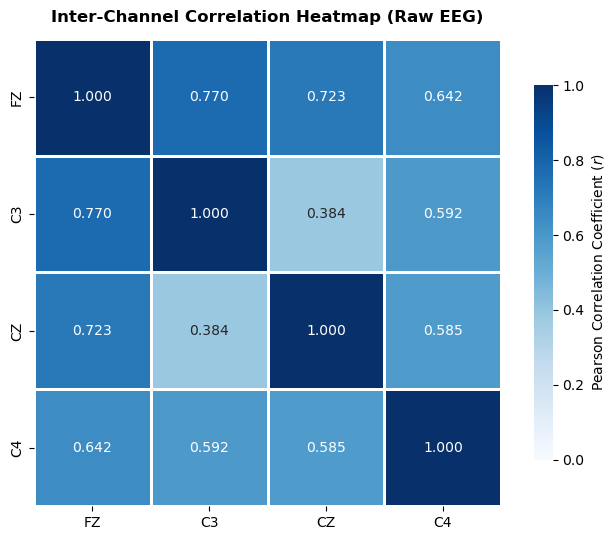

In [22]:
# 1. Compute pairwise Pearson correlation matrix across target EEG channels
corr_matrix = full_eeg_df[eeg_channels].corr()

# 2. Configure visualization figure dimensions
plt.figure(figsize=(7, 5.5))

# Generate upper-triangle mask to eliminate redundant duplicate values (professional layout)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Render heatmap representation of inter-channel signal correlation
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".3f", 
    cmap="Blues", 
    vmin=0, vmax=1,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient ($r$)"}
)

# Apply chart title and format axis layouts
plt.title("Inter-Channel Correlation Heatmap (Raw EEG)", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 24. Analytical Interpretation of Inter-Channel Pearson Correlations

The Pearson correlation matrix provides critical insights into the spatial relationship and signal redundancy across scalp electrodes (`FZ`, `C3`, `CZ`, `C4`) prior to preprocessing:

**1. High Frontal-Central Coupling ($r = 0.723 – 0.770$)**
* `FZ` exhibits high positive correlation with `C3` ($r = 0.770$) and `CZ` ($r = 0.723$). 
* This strong baseline correlation is heavily driven by common low-frequency artifacts (e.g., ocular movements and slow-wave baseline drift) and high-amplitude $50\text{ Hz}$ power line interference shared across all recording channels.

**2. Moderate Hemispheric Independence ($r = 0.592$)**
* The motor cortex channels targeting left (`C3`) and right (`C4`) hemispheres show a moderate correlation of $r = 0.592$.
* While shared reference noise and volume conduction induce common baseline activity, the distinct spatial placement preserves localized motor imagery dynamics across hemispheres.

**3. Distinct Central-Lateral Pattern ($r = 0.384$)**
* The lowest correlation in the matrix occurs between `C3` (left motor cortex) and `CZ` (midline central), registered at $r = 0.384$.
* This relative independence indicates that `C3` captures unique localized sensorimotor rhythm variations separate from the central vertex.

**Pipeline Implications & Next Steps:**
* **Artifact Driven High Baseline Correlations:** Filtering out global noise ($50\text{ Hz}$ power line and low-frequency drift) will decouple artifact-induced similarities and expose subtle neural dynamics.
* **Spatial Filtering Justification:** The presence of shared spatial noise supports using spatial referencing methods—such as Common Average Referencing (CAR), Surface Laplacian, or Common Spatial Patterns (CSP)—to maximize class separability during Motor Imagery tasks.

### 25. Pairwise Feature Distribution and Bivariate Relationship Analysis

We generate a pairwise scatter plot matrix (pairplot) sampled from $5,000$ representative observations to inspect channel-to-channel bivariate relationships and single-channel univariate feature distributions split by Motor Imagery classes (`left` vs. `right`).

* **Diagonal Plots (Kernel Density Estimation - KDE):** Evaluates single-channel amplitude distributions for each target electrode (`FZ`, `C3`, `CZ`, `C4`).
* **Off-Diagonal Plots (Scatter Plots):** Examines cross-channel linear dependencies, spatial clusters, and raw amplitude overlaps across movement conditions.

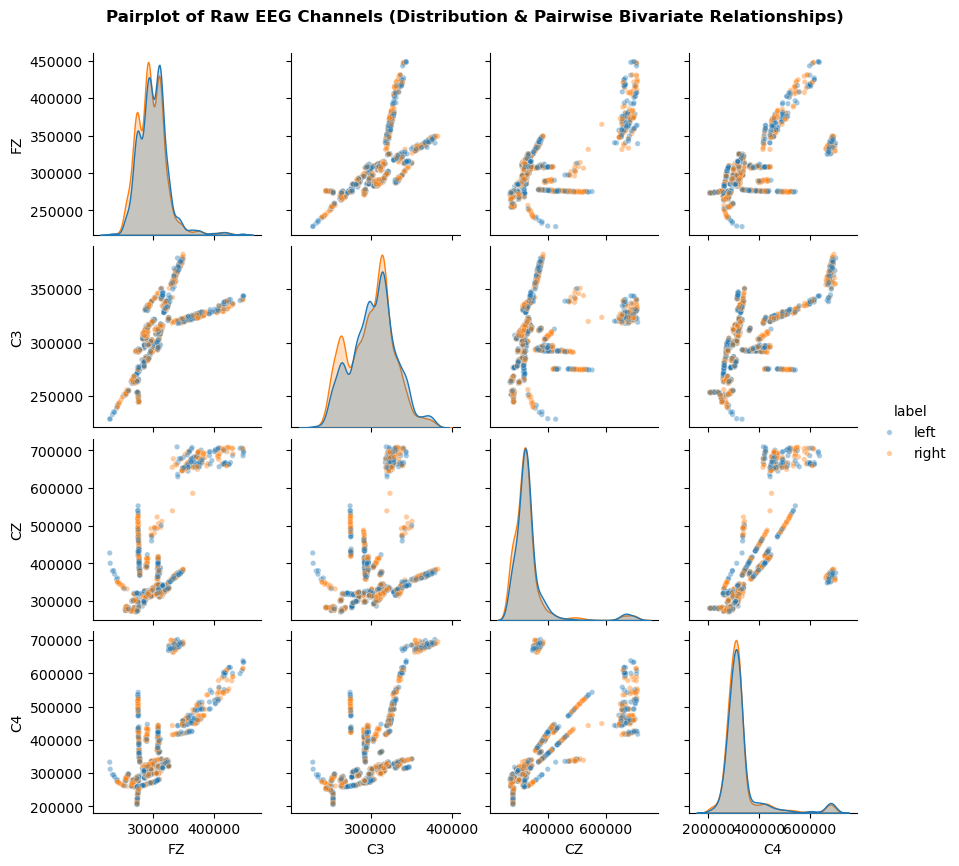

In [23]:
# Sample a random representative subset (n=5000) to optimize rendering speed
sample_df = full_eeg_df[eeg_channels + ["label"]].sample(n=5000, random_state=42)

# 1. Generate pairwise scatter plot matrix with KDE diagonal distributions
g = sns.pairplot(
    sample_df,
    hue="label",
    palette={"left": "#1f77b4", "right": "#ff7f0e"},
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    height=2.2
)

# Adjust layout title spacing and apply main section heading
g.fig.subplots_adjust(top=0.93)
g.fig.suptitle("Pairplot of Raw EEG Channels (Distribution & Pairwise Bivariate Relationships)", fontsize=12, fontweight="bold")

# Display visualization grid
plt.show()

### 26. Analytical Interpretation of Raw Bivariate Distributions (Pairplot)

The pairwise scatter plot matrix and kernel density estimations (KDE) across raw channels (`FZ`, `C3`, `CZ`, `C4`) provide critical diagnostic insights into signal characteristics prior to preprocessing:

**1. Complete Raw Class Overlap**
* Across all pairwise scatter plots (off-diagonal) and single-channel KDE distributions (diagonal), the `left` (blue) and `right` (orange) motor imagery classes overlap almost completely.
* **Key Takeaway:** Raw time-series amplitude values carry zero linear or spatial separability for motor imagery classification, confirming that time-domain raw voltages cannot be directly used as input features for machine learning models.

**2. Off-Scale Amplitude Dynamics & Non-Stationary Clustered Structures**
* Amplitude values span massive ranges ($\approx 200,000\text{ to } 700,000 \ \mu\text{V}$), reflecting high uncalibrated DC offsets and large baseline variations between different recording sessions/trials.
* Distinct linear arms and localized clusters in the off-diagonal scatter plots indicate common-mode artifacts—specifically high-amplitude low-frequency drifts and phase-locked $50\text{ Hz}$ power line interference affecting all channels simultaneously.

**3. Skewed Univariate Distributions (Diagonal KDEs)**
* Channels `CZ` and `C4` show heavy right-skewed tails extending toward $700,000 \ \mu\text{V}$, flagging transient muscle artifacts, ocular blinks, or electrode motion spikes.
* `FZ` and `C3` display multi-modal amplitude distributions, further emphasizing baseline instability across recording blocks.

**Pipeline Justifications & Preprocessing Directives:**
* **Bandpass & Spatial Filtering Essential:** Standard frequency filtering ($8–30\text{ Hz}$) combined with spatial methods (e.g., CSP or Laplacian) is required to remove common-mode noise and isolate event-related desynchronization (ERD) dynamics.
* **Feature Engineering Required:** Linear classification models require spectral power density or log-variance band power features calculated per trial window rather than raw instant voltage values.